# 합성곱 신경망을 사용한 컴퓨터비전

## 개요
### 정의
> 합성곱 신경망이란, 이미지와 같은 시각적 데이터를 처리하기 위해 고안된 심층 신경망의 한 종류

### 적용 분야
- 자율주행, 이미지 검색, 영상 자동 분류 시스템
- 음성 인식 및 자연어 처리 등

----

In [2]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

import sys
# 코랩의 경우 나눔 폰트를 설치합니다.
if 'google.colab' in sys.modules:
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

# 나눔 폰트를 사용합니다.
import matplotlib

matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126284 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


# 1. 시각 피질 구조

- `국부 수용장` : 시각 피질의 많은 뉴런은 시야의 특정 부분(작은 국부 수용장)에서 오는 시각 자극에만 반응
- `층적 패턴 감지`: 일부 뉴런은 수평선이나 특정 각도의 선분과 같은 단순한 패턴에 반응
  - 더 복잡한 뉴런은 저수준 패턴들이 조합된 복잡한 패턴에 반응
  -고수준 뉴런이 저수준 뉴런의 출력에 기반
  - 계층적 구조를 통해 전체 시야의 복잡한 패턴을 감지
- `CNN`에의 영감: 이러한 시각 피질 연구는 1980년대에 소개된 신인식기(Neocognitron)에 영향
  - 신인식기의 아이디어는 합성곱 신경망(CNN)의 핵심 구성 요소인 `합성곱 층`과 `풀링 층`의 개발에 영감

----

# 2. 합성곱 층

## 개요
- 이미지 같은 시각적 데이터를 효율적으로 처리하기 위해 설계된 층

### 원리
- ~~이미지의 모든 픽셀 연결 (X) ~~
- 합성곱 층 뉴런의 수용장 안에 있는 픽셀에만 연결됨
- 다음 합성곱 층은 첫번째 층의 사각 영역의 뉴런에 연결
- 첫번째 은닉층 (저수준) → 마지막 은닉층(고수준)

### 스트라이드 (Stride)
> 합성곱 필터가 입력 이미지 위를 이동하는 보폭

- 필터가 한 번에 얼마나 멀리 이동하며 다음 계산을 수행할지를 결정

- 일반적으로는  스트라이드는 수평 및 수직 방향으로 동일하게 적용

- 스트라이드가 커지면 모델의 계산 복잡도가 크게 줄어듦

#### 스트라이드 구하는 법
- 합성곱층에는 여러 뉴런이 있음
- n번째 층 $i$행, $j$열
    - 행 :  n-1 층의 $i$에서 $i+f_h$-1행까지의 행
       - $f_w$ : 뉴런 수용장의 너비
    - 열 : $j$에서 $j+f_w-1$까지 열에 있는 뉴런이 출력
     - $f_h$ : 뉴런 수용장의 높이
- `제로페딩` : 높이와 너비를 이전 층과 같게 입력하기 위해 입력 주위에 0을 추가하는 것

- $s_h$ : 스트라이드 수직 값
- $s_w$ : 스트라이드 수평 값

- 행 : $i \times s_h$ ~ $i \times s_h + f_h -1$
- 열 :$j \times s_w$ ~ $j \times s_w + f_h -w$

- 예시 : 스트라이드 2
  - 필터가 가로 세로 방향으로 2픽셀씩 건너뛰며 이동

<br/>

----

## 필터

### 정의
> 필터 (합성곱 커널, 커널)는 입력 이미지 위를 이동하며 `특정 특성`을 감지
- 예시 : 수직선 필터 = 이미지의 수직선만 강조되고 나머지는 무시

### 특성 맵
- 필터가 입력 이미지에서 특성을 감지하고 출력하는 결과
- 하나의 필터는 하나의 특성 맵을 만들어냄

<br/>

----

## 여러 가지 특성 맵 쌓기

- 합성곱 층의 출력은 2D층이 아닌 `3D`로 표현됨
  - 여러 필터 마다 하나의 특성 맵 출력
  - 3D로 표현됨
<br/>

- 하나의 합성곱 층은 입력에 여러 필터를 동시에 적용하여 입력에 있는 여러 특성 감지
- 예시 : `컬러 채널`
  - 각 색성 채널마다 별도의 필터가 적용됨
<br/>

### 합성곱 층에 있는 뉴런 출력 계산
- $l$ : 합성곱 층
- $k$ : 특성 맵
- 특성 맵 $k$의 $i$행, $j$열에 위치한 뉴런
- 이전 층 $l-1$층의 모든 특성 맵에서 아래 범위의 뉴런 출력과 연결
  - 행 : $i \times s_h$ 에서 $i \times s_h + f_h -1$
  - 열 : $j \times s_w$ 에서 $j \times s_w + f_w -1$
  
<br/>

----


## 케라스로 합성곱 층 구현

### 이미지 로드 및 전처리
- 사이킷런의 `load_sample_image()`로 샘플 이미지 로드
- 케라스의 `CenterCrop`과 `Rescaling` 층으로 전처리

In [3]:
from sklearn.datasets import load_sample_images
import tensorflow as tf

### 샘플 이미지 로드
images = load_sample_images()["images"]

### 전처리 - 중앙 크롭 + 크기 변경
images = tf.keras.layers.CenterCrop(height=70, width=120)(images)
images = tf.keras.layers.Rescaling(scale=1 / 255)(images)

### 이미지 텐서 크기 확인
print("텐서 크기 - images.shape : ", images.shape)

텐서 크기 - images.shape :  (2, 70, 120, 3)


- 텐서의 크기가 `4D`
  - 첫번째 차원 : 샘플 이미지의 수 (2개 이미지)
  - 두번째 차원 , 세번째 차원 : 이미지의 크기 (70X 120)
  - 네번째 차원 : 컬러 채널 수 (3개 컬러 채널)

### Conv2D
- 2D 합성곱 층 생성 후 이미지 주입
- 케라스 `Convolution2D` 층 으로 합성곱층 생성
  - 텐서플로 내 `tf.nn.conv2d()` 연산을 이용
  - `kernel_size` : 필터의 크기 결정
- 2개 이미지로 구성된 작은 배치에 적용

- `Conv2D`는 `제로패딩`을 기본적으로 사용 하지 않음
  - 가장자리에 픽셀을 잃음

In [4]:
tf.random.set_seed(42)

### 7x7 필터 32개 생성
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7)
fmaps = conv_layer(images)

print("출력의 크기 : fmaps.shape", fmaps.shape)

출력의 크기 : fmaps.shape (2, 64, 114, 32)


- 출력 특성 맵 표시

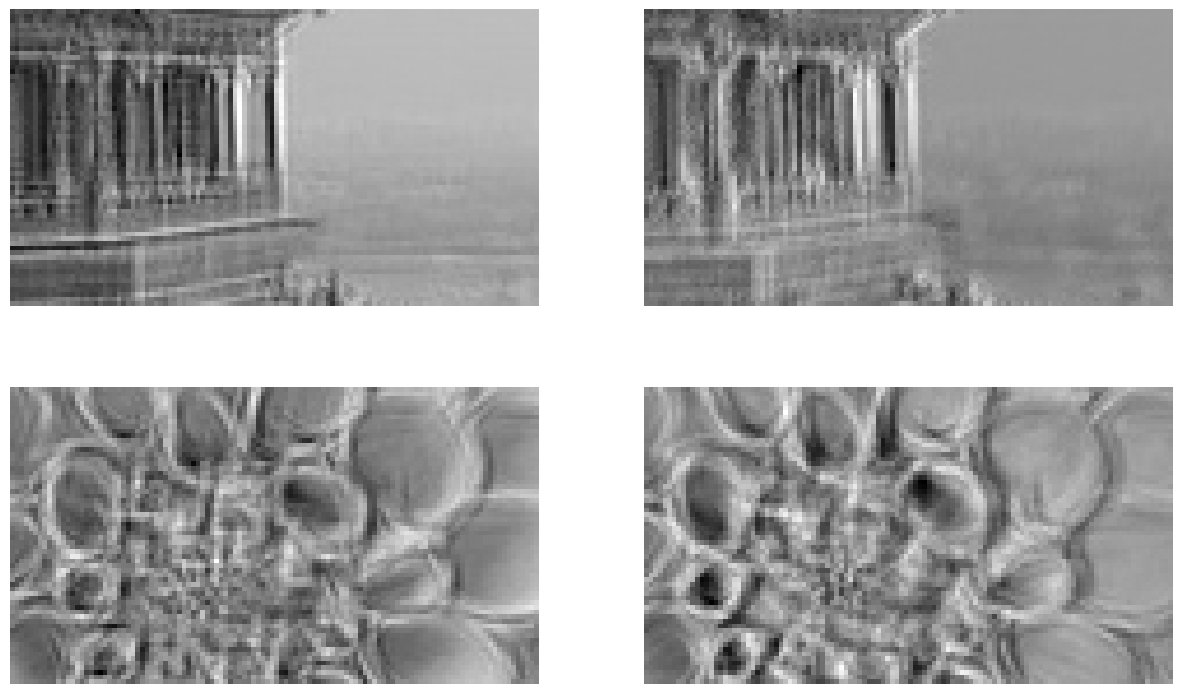

In [5]:
plt.figure(figsize=(15, 9))
for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, :, :, fmap_idx], cmap="gray")
        plt.axis("off")

plt.show()

- `제로패딩` 적용
  - `padding="same"` : 출력 특성맵이 입력과 같은 크기가 되도록 패팅 추가

In [6]:
### 제로 패딩 적용
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7,
                                    padding="same")
fmaps = conv_layer(images)

print("출력의 크기 : fmaps.shape", fmaps.shape)

출력의 크기 : fmaps.shape (2, 70, 120, 32)


- 스트라이드 2 예시
  - `strides=2`의 출력 크기

In [7]:
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7, padding="same",
                                    strides=2)
fmaps = conv_layer(images)

print("출력의 크기 : fmaps.shape", fmaps.shape)

출력의 크기 : fmaps.shape (2, 35, 60, 32)


### 층 가중치
- 커널과 편향을 포함해 모든 가중치를 가지고 있음
- `weights` 속성을 통해 텐서플로 변수나 `get_weights()` 함수로 참조 가능
- 단, 입력 이미지의 높이와 너비가 커널 크기에 나오지 않음
  - 출력 특성 맵에 있는 모든 뉴런이 `동일한 가중치`를 공유

In [8]:
kernels, biases = conv_layer.get_weights()
print("kernels.shape [kernel_height, kernel_width, input_channels, output_channels]: \n",kernels.shape)
print("biases.shape [output_channels]: ",biases.shape)

kernels.shape [kernel_height, kernel_width, input_channels, output_channels]: 
 (7, 7, 3, 32)
biases.shape [output_channels]:  (32,)


- `tf.nn.conv2d()`로 합성곱 연산 수행
  - 첫번째 필터 - 수직선 = 1 , 나머지 = 0
  - 두번째 필터 - 수평선 = 1 , 나머지 = 0

  - 합성곱 층이 필터를 자동으로 학습하기 때문에 아래와 같이 수동으로 만들 필요는 없음

  - 제로 패딩을 사용했기 때문에 상단 하단 근처에서 활성화 되지 않음 -> 그래서 선이 생성됨

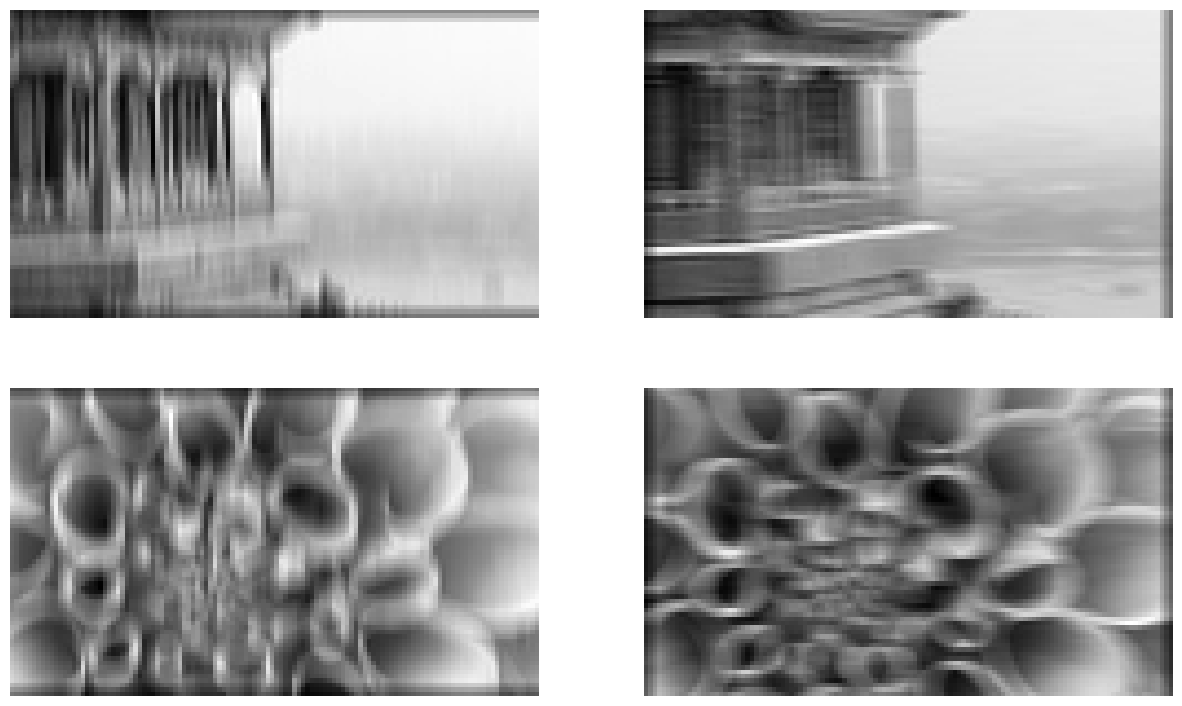

In [9]:
import numpy as np

tf.random.set_seed(42)
filters = tf.random.normal([7, 7, 3, 2])
biases = tf.zeros([2])
fmaps = tf.nn.conv2d(images, filters, strides=1, padding="SAME") + biases

plt.figure(figsize=(15, 9))
filters = np.zeros([7, 7, 3, 2])
filters[:, 3, :, 0] = 1
filters[3, :, :, 1] = 1
fmaps = tf.nn.conv2d(images, filters, strides=1, padding="SAME") + biases

for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, :, :, fmap_idx], cmap="gray")
        plt.axis("off")

plt.show()

- Conv2D층 생성 시 활성화 함수와 커널초기화 방법을 지정
  - 선형 연산을 수행
  - 활성화 함수 없이 여러 합성곱 층을 쌓아도 하나의 합성곱 층과 동일해짐 -> 학습이 없음

  <br/>

  -----

## 메모리 요구사항
- CNN의 문제 : 많은 RAM이 필요
- 이유 : 훈련하는 동안 `역전파 알고리즘`이 정방향 계산의 중간 값을 모두 필요로 함
  - 계산량이 매우 많아짐

----

# 3. 풀링 층

## 정의
> 입력 데이터의 공간 크기를 줄여주는 역할을 하는 신경망 계층

## 목적
- 계산량과 메모리 사용량, 과대적합, 파라미터를 줄이기 위한 `부표본(subsampling)` 생성

## 원리
- `풀링층`은 **가중치가 없음**
- 즉, `최대` 혹은 `평균`과 같은 합산 함수를 이용해 입력을 더하는 것이 전부

## 최대 풀링층
- 각 수용장에서 `가장 큰 입력값`이 다음층으로 전달
- 이외의 값은 무시

### 장점 : 최대 풀링층의 이동불변성
-  입력 이미지가 약간 이동하더라도(예: 객체가 몇 픽셀 이동하는 경우) 풀링 층의 출력이 크게 변하지 않음
- 분류 작업에서 객체의 정확한 위치에 관계없이 객체를 인식할 수 있게함

### 단점 : 파괴적임
- 항상 입력값의 n%를 잃게 됨
- 불변성이 필요 없는 애플리케이션에서는 `등변성`이 목표가 됨

<br/>

----

# 4. 케라스로 풀링 층 구현

## 최대 풀링 구현
- 케라스의 `MaxPool2D` 사용

- 예시 2D 풀링층 + 이미지 출력
  - 2x2 커널 사용층 생성
  - vaild 패딩 사용 (패딩 없음)
  - 이미지 생성

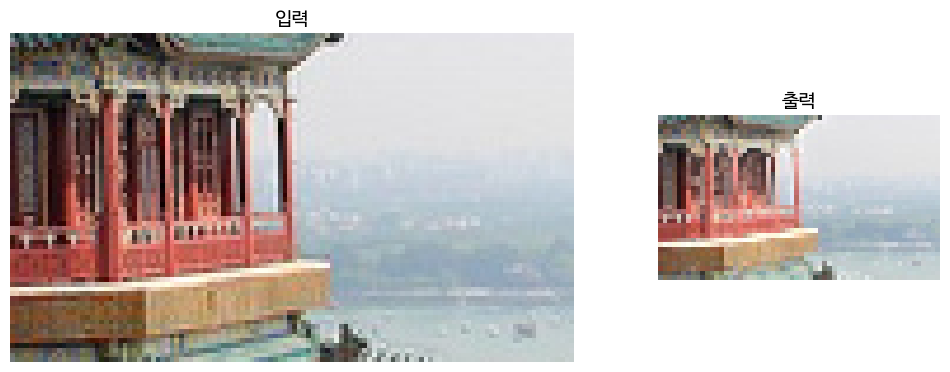

In [10]:
### 최대 풀링층 생성
max_pool = tf.keras.layers.MaxPool2D(pool_size=2)
output = max_pool(images)

### 이미지 출력
import matplotlib as mpl

fig = plt.figure(figsize=(12, 8))
gs = mpl.gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[2, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("입력")
ax1.imshow(images[0])
ax1.axis("off")
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title("출력")
ax2.imshow(output[0])
ax2.axis("off")
plt.show()

## 평균풀링층
- `AveragePoolin2D` 층 사용
- `최대` 대신 `평균`을 사용하는 것을 제외하면 동일

- 장점 : 최대풀링층 보다 정보손실이 적음
- 단점 : 연산 비용 또한 증가하는 경향

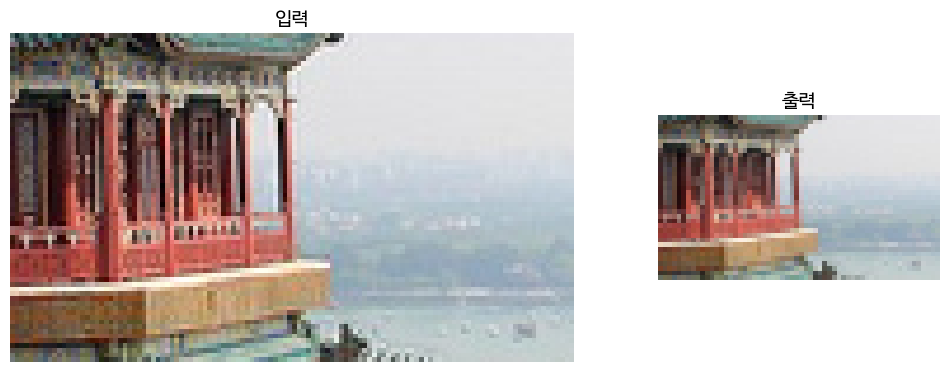

In [11]:
### 평균 풀링층 생성
avg_pool = tf.keras.layers.AveragePooling2D(pool_size=2)
output = avg_pool(images)

### 이미지 출력
import matplotlib as mpl

fig = plt.figure(figsize=(12, 8))
gs = mpl.gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[2, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("입력")
ax1.imshow(images[0])
ax1.axis("off")
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title("출력")
ax2.imshow(output[0])
ax2.axis("off")
plt.show()

## 깊이 방향 최대 풀링
- 케라스 미지원

- 예시 : 사용자 정의층을 이용한 `깊이 방향 최대풀링층` 구현
  - 입력 채널을 원하는 크기(pool_size)의 그룹으로 나누어 각 그룹에서 가장 큰 값을 계산
  - 스트라이드가 풀링 크기와 같다고 가정

  - max_pool() 연산자를 사용하는 방법 (cpu에서만 가능)

In [12]:
np.random.seed(42)
fmaps = np.random.rand(2, 70, 120, 60)
with tf.device("/cpu:0"):
    output = tf.nn.max_pool(fmaps, ksize=(1, 1, 1, 3), strides=(1, 1, 1, 3),
                            padding="VALID")
output.shape

TensorShape([2, 70, 120, 20])

- 사용자 정의층 사용

In [13]:
class DepthPool(tf.keras.layers.Layer):
    def __init__(self, pool_size=2, **kwargs):
        super().__init__(**kwargs)
        self.pool_size = pool_size

    def call(self, inputs):
        shape = tf.shape(inputs)  # shape[-1]는 채널 개수입니다.
        groups = shape[-1] // self.pool_size  # 채널 그룹 수
        new_shape = tf.concat([shape[:-1], [groups, self.pool_size]], axis=0)
        return tf.reduce_max(tf.reshape(inputs, new_shape), axis=-1)

- 차이 비교 : 둘의 값은 동일

In [14]:
np.allclose(DepthPool(pool_size=3)(fmaps), output)

True

- 이미지 출력

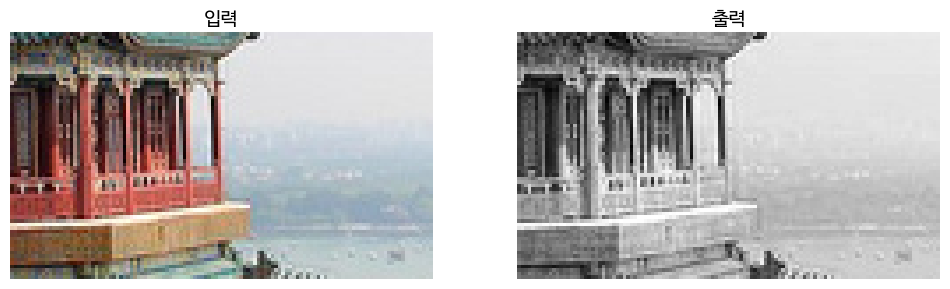

In [15]:
depth_output = DepthPool(pool_size=3)(images)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.title("입력")
plt.imshow(images[0])  # 첫 번째 이미지를 그립니다.
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title("출력")
plt.imshow(depth_output[0, ..., 0], cmap="gray")  # 첫 번째 이미지의 출력을 그립니다.
plt.axis("off")
plt.show()

## 전역 평균 풀링
- 특성 맵의 모든 픽셀의 평균을 계산하여 하나의 숫자를 출력
- 출력층 직전에 사용 시 유용하게 가능
- 케라스의 `GlobalAvgPool2D`로 구현

- 예시 : 전역 평균 풀링층 생성

In [16]:
global_avg_pool = tf.keras.layers.GlobalAvgPool2D()

- 공간 방향을 따라 평균을 계산하는 `Lambda`층과 동일

In [17]:
global_avg_pool = tf.keras.layers.Lambda(
    lambda X: tf.reduce_mean(X, axis=[1, 2]))

- 단 하나의 값만 출력
  - 이미지의 RGB  색의 평균 강도를 얻을 수 있음

In [18]:
global_avg_pool(images)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[0.643388  , 0.59718215, 0.5825038 ],
       [0.7630747 , 0.26010972, 0.10848834]], dtype=float32)>

----

# 5. CNN의 구조

## 개요
- 합성곱 층 + 활성화 함수 (ReLU) + 풀링층 : 이미지는 작아지지만 특성 맵은 많아짐 (=깊어짐)
- 완전연결층 : 피드 포워드망
- 소프트맥스층 : 예측 출력

### 주의 사항
- 첫번째 합성곱에 매우 큰 커널 설정 + 스트라이드 2 이상 설정
  - 중요한공간 정보를 잃어버릴 수 있음
  - 대안 : 첫번째 합성곱은 작은 커널 + 스트라이드 1로 설정

- 예시 : MNIST 데이터 학습
  - 데이터 셋 분할
  - MNIST 데이터 학습
  - 모델 컴파일 및 예측

- 데이터셋 분할

In [19]:
### MNIST 데이터 분할
mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = mnist
X_train_full = np.expand_dims(X_train_full, axis=-1).astype(np.float32) / 255
X_test = np.expand_dims(X_test.astype(np.float32), axis=-1) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


- 데이터 학습

In [20]:
from functools import partial

tf.random.set_seed(42)
DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, padding="same",
                        activation="relu", kernel_initializer="he_normal")
model = tf.keras.Sequential([
    DefaultConv2D(filters=64, kernel_size=7, input_shape=[28, 28, 1]),
    tf.keras.layers.MaxPool2D(),
    DefaultConv2D(filters=128),
    DefaultConv2D(filters=128),
    tf.keras.layers.MaxPool2D(),
    DefaultConv2D(filters=256),
    DefaultConv2D(filters=256),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=64, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=10, activation="softmax")
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


- 모델 컴파일, 훈련, 평가

In [21]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))
score = model.evaluate(X_test, y_test)
X_new = X_test[:10]
y_pred = model.predict(X_new)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 33s 13ms/step - accuracy: 0.6185 - loss: 1.0660 - val_accuracy: 0.8700 - val_loss: 0.3848
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8422 - loss: 0.4604 - val_accuracy: 0.8902 - val_loss: 0.2947
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8753 - loss: 0.3617 - val_accuracy: 0.8932 - val_loss: 0.2967
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8921 - loss: 0.3208 - val_accuracy: 0.9042 - val_loss: 0.2644
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9028 - loss: 0.2849 - val_accuracy: 0.9014 - val_loss: 0.2755
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9104 - loss: 0.2631 - val_accuracy: 0.9032 - val_loss: 0.2730
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9152 - loss: 0.2551 - val_accuracy: 0.9084 - val_loss: 0.2523
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9210 - loss:

## LeNet-5

### 특징
- 최초이자 가장 널리 알려진 CNN 구조
- 여러 합성곱 층 및 평균 풀링층이 번갈아서 나오고 마지막에 완전연걸층이 나옴

- 층 구성 :
<br/>

| 층   | 특성 맵 | 크기    | 커널 크기 | 스트라이드 | 활성화 함수 |
| ---- | ---- | ----- | ----- | ----- | ------ |
| F6  |      | 10    |       |       | RBF    |
| C5  | 120  | 1x1   | 5x5   | 1     | tanh   |
| S4  | 16   | 5x5   | 2x2   | 2     | tanh   |
| C3  | 16   | 10x10 | 5x5   | 1     | tanh   |
| S2  | 6    | 14x14 | 2x2   | 2     | tanh   |
| C1  | 6    | 28x28 | 5x5   | 1     | tanh   |
| 입력  | 입력   | 32x32 |       |       |        |

<br/>

### 활성화 함수
- `tanh` 함수

## AlexNet

### 특징
- LeNet-5 보다 `깊은 구조`
- 첫 합성곱 층 바로 뒤에 풀링층을 사용하지 않음

#### 지역 반응 정규화 (LRN)
- 경쟁적인 정규화 단계 (C1, C3)
- 가장 강하게 활성화된 뉴런이 다른 특성 맵에 있는 같은 위치 뉴런 억제
- 일반화 성능 향상
- 식 : $ b_i = a_i \left( k + \alpha \sum_{j=j_{\text{low}}}^{j_{\text{high}}} a_j^2 \right)^{-\beta}$

  - 이 때, j는 $\begin{cases}
j_{\text{high}} = \min\left(i + \frac{r}{2}, f_n - 1\right) \\
j_{\text{low}} = \max\left(0, i - \frac{r}{2}\right)
\end{cases}$

<br/>

#### 과적합 방지
- 드롭 아웃(50%)
- 광범위한 데이터 증식

### 활성화 함수
- `ReLU` 함수
  - 훈련속도 상승



### 층 구조

| 층     | 특성 맵   | 크기      | 커널 크기 | 스트라이드 | 패딩    | 활성화 함수 |
| ----- | ------ | ------- | ----- | ----- | ----- | ------ |
| F10   |        | 1,000   |       |       |       | 소프트맥스  |
| F9    |        | 4,096   |       |       |       | ReLU   |
| F8    |        | 4,096   |       |       |       | ReLU   |
| C7    | 256    | 6x6     | 3x3   | 2     | valid | ReLU   |
| C6    | 384    | 13x13   | 3x3   | 1     | same  | ReLU   |
| C5    | 384    | 13x13   | 3x3   | 1     | same  | ReLU   |
| S4    | 256    | 13x13   | 3x3   | 1     | valid | ReLU   |
| C3    | 256    | 27x27   | 3x3   | 1     | same  | ReLU   |
| S2    | 96     | 27x27   | 3x3   | 2     | valid | ReLU   |
| C1    | 96     | 55x55   | 11x11 | 4     | valid | ReLU   |
| input | 3(RGB) | 227x227 |       |       |       |        |

## GoogLeNet

### 특징
- AlexNet 보다 적은 파라미터로 뛰어난 성능 달성
- 1x1 합성곱 (bottleneck layer)를 이용하여 `차원 축소` 및 `계산량 감소`-> 효율성 증가
- 전역 평균 풀링을 최종 완전 연결층 대신 사용
  - 파라미터 수 감소

#### 인셉션 모듈
- 여러 크기의 합성곱 필터와 최대 풀링층을 `병렬로 실행`
- 출력들의 `깊이 방향`으로 연결
- 다양한 스케일의 패터 동시 학습